# **Assignment 2: Exploratory Data Analysis (EDA) for Asset Price Analysis**

# 1. Data Collection and Organizing

# 1.1. Collecting and Organizing Stock Data

Firstly, I will collect the stock data for SPY, TSLA, GM, and NVDA. I will use the yfinance library to fetch the data, and then I will append the data for each stock into a single dataset called "df". I will also print the first 15 datapoints to ensure the data is loaded correctly.

In [ ]:
# Import necessary libraries
import matplotlib.pyplot as plt
from pandas_datareader import data as pdr
import pandas as pd
import yfinance as yf

# Define the stock tickers - I will track SPY, TSLA, GM, and NVDA
# I chose Nvidia (NVDA) as the 4th stock ticker for this analysis
stocks = ['SPY', 'TSLA', 'GM', 'NVDA']

# Initialize a list to store individual DataFrames for each stock
data_frames = []

# Loop through each stock ticker and fetch historical stock data
for stock in stocks:
    # Fetch the historical data for the stock from Yahoo Finance
    df_temp = yf.Ticker(stock).history(period='1y', auto_adjust=True)  # I download 1 year of daily data
    df_temp['Company'] = stock  # I add a new column to identify which company the data belongs to
    df_temp.reset_index(inplace=True)  # I reset the index to ensure 'Date' becomes a column
    data_frames.append(df_temp)  # I append each stock data to the list

# Combine all the stock data into one long dataset (long format)
df = pd.concat(data_frames)

# Print the first 15 data points of the combined dataset
# This shows me the beginning of the dataset with stock prices for the 4 companies (SPY, TSLA, GM, and NVDA)
print("First 15 datapoints of df:")
print(df.head(15))

First 15 datapoints of df:
                        Date        Open        High         Low       Close  \
0  2024-02-15 00:00:00-05:00  492.966577  495.839726  492.482763  495.652130   
1  2024-02-16 00:00:00-05:00  495.346043  496.501208  492.433393  493.183777   
2  2024-02-20 00:00:00-05:00  491.416461  492.097725  488.187886  490.468628   
3  2024-02-21 00:00:00-05:00  489.145595  491.070880  487.309136  490.912903   
4  2024-02-22 00:00:00-05:00  497.626811  502.050053  496.649329  501.072601   
5  2024-02-23 00:00:00-05:00  502.820181  503.669305  500.677681  501.418182   
6  2024-02-26 00:00:00-05:00  501.862468  502.306781  499.453368  499.581726   
7  2024-02-27 00:00:00-05:00  500.282698  500.736864  498.357382  500.509766   
8  2024-02-28 00:00:00-05:00  498.930053  500.440674  498.564743  499.848297   
9  2024-02-29 00:00:00-05:00  501.635411  503.284244  498.949858  501.645264   
10 2024-03-01 00:00:00-05:00  502.533845  506.789227  502.119151  506.354797   
11 2024-03-04

# 1.2. Sorting the Data

Now, I will sort the "df" dataset by the company name and the date, with the newest data first. I will then store this sorted data in a new variable called "df_sorted". After sorting, I will print the first 15 rows to confirm the sorting has been done correctly.

In [ ]:
# Now, I will sort the combined data by company name and the date (newest to oldest)
# This ensures that the data is organized first by the company, and then by date in descending order
df_sorted = df.sort_values(by=['Company', 'Date'], ascending=[True, False])

# Print the first 15 data points of the sorted dataset
# This shows me the result of sorting by company and date (most recent data appears first)
print("First 15 datapoints of df_sorted:")
print(df_sorted.head(15))

First 15 datapoints of df_sorted:
                         Date       Open       High        Low      Close  \
250 2025-02-14 00:00:00-05:00  48.389999  48.680000  47.919998  48.369999   
249 2025-02-13 00:00:00-05:00  48.139999  48.630001  47.349998  47.889999   
248 2025-02-12 00:00:00-05:00  46.419998  47.990002  46.259998  47.689999   
247 2025-02-11 00:00:00-05:00  46.360001  46.840000  46.259998  46.700001   
246 2025-02-10 00:00:00-05:00  47.400002  47.599998  46.439999  46.570000   
245 2025-02-07 00:00:00-05:00  47.689999  48.320000  47.209999  47.389999   
244 2025-02-06 00:00:00-05:00  47.990002  48.389999  47.439999  47.930000   
243 2025-02-05 00:00:00-05:00  48.709999  48.790001  47.740002  47.810001   
242 2025-02-04 00:00:00-05:00  47.169998  48.939999  47.110001  48.570000   
241 2025-02-03 00:00:00-05:00  46.500000  49.230000  46.369999  47.900002   
240 2025-01-31 00:00:00-05:00  49.669998  51.730000  49.180000  49.459999   
239 2025-01-30 00:00:00-05:00  50.450001  

# 1.3. Creating a Wide Format Dataset with Close Prices

Finally, I will create a new dataset, "df_close", which will only keep the closing prices for each stock. I will transform the data from a long format (with one row per stock per day) into a wide format (with one row per date and separate columns for each stock’s closing price).

In [ ]:
# Create a new dataset that keeps only the closing price for each stock
# This is a transformation that changes the data from long format (one row per stock per day) into wide format (one row per date)
# The first column will be 'Date', and the next columns will represent the closing prices for each stock
df_close = df.pivot(index='Date', columns='Company', values='Close').reset_index()

# Print the first few rows of the transformed dataset (df_close)
# This shows me the stock data in a wide format, with dates as rows and each stock's closing price as columns
print("First few rows of df_close:")
print(df_close.head())

First few rows of df_close:
Company                      Date         GM       NVDA         SPY  \
0       2024-02-15 00:00:00-05:00  38.589005  72.637398  495.652130   
1       2024-02-16 00:00:00-05:00  38.301991  72.592415  493.183777   
2       2024-02-20 00:00:00-05:00  38.608799  69.432312  490.468628   
3       2024-02-21 00:00:00-05:00  39.083866  67.452881  490.912903   
4       2024-02-22 00:00:00-05:00  38.935406  78.515747  501.072601   

Company        TSLA  
0        200.449997  
1        199.949997  
2        193.759995  
3        194.770004  
4        197.410004  


**Question 1: How many datapoint do we have for each company a year? Why don’t we have 365 datapoints for a year?**

In [ ]:
# Calculate how many data points there are for each company in the dataset (df)
# We will group by 'Company' and count the number of rows (data points) for each company
data_points_per_company = df.groupby('Company').size()

# Print the number of data points for each company
print("Number of data points for each company:")
print(data_points_per_company)

# Answer to the question
# We don't have 365 datapoints because stock market data typically includes only trading days (business days).
# Weekends (Saturdays and Sundays) and market holidays are excluded from the data.

Number of data points for each company:
Company
GM      251
NVDA    251
SPY     251
TSLA    251
dtype: int64


**Question 2: What is the data type of stock prices? Cross-section, time series, or panel data?**

In [ ]:
# Check the structure of the data and data types
print(df.info())

# Display the first few rows of the DataFrame
print(df.head())

<class 'pandas.core.frame.DataFrame'>
Index: 1004 entries, 0 to 250
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype                           
---  ------         --------------  -----                           
 0   Date           1004 non-null   datetime64[ns, America/New_York]
 1   Open           1004 non-null   float64                         
 2   High           1004 non-null   float64                         
 3   Low            1004 non-null   float64                         
 4   Close          1004 non-null   float64                         
 5   Volume         1004 non-null   int64                           
 6   Dividends      1004 non-null   float64                         
 7   Stock Splits   1004 non-null   float64                         
 8   Capital Gains  251 non-null    float64                         
 9   Company        1004 non-null   object                          
dtypes: datetime64[ns, America/New_York](1), float64(7), int64(1), obje

# 2. Statistics

# 2.1. Calculate Basic Statistics for Each Stock

Firstly, I will calculate basic statistics for each stock, including the minimum close price, maximum close price, average close price, and standard deviation of the close prices. These statistics will provide an overview of how each stock has performed over the selected time period.

In [ ]:
# Step 1: Calculate basic statistics (min, max, avg, std) for each stock

# Calculate statistics for the 'Close' price column for each company
stats = df.groupby('Company')['Close'].agg(['min', 'max', 'mean', 'std']).round(2)

# Print the table of statistics
print("Basic Statistics for Each Stock:")
print(stats)

Basic Statistics for Each Stock:
            min     max    mean    std
Company                               
GM        38.30   60.06   47.22   4.60
NVDA      67.45  149.43  116.71  21.32
SPY      490.41  609.75  552.06  35.67
TSLA     142.05  479.86  252.67  87.14


# 2.2. Calculate the Annual Return for Each Stock

In this step, I will calculate the annual return for each stock using the following formula:

<br> Annual Return = (Final Close – Initial Close) / Initial Close

<br> The return will be calculated based on the first and last closing prices in the dataset. I will then format the return as a percentage with two decimal places.

In [ ]:
# Step 2: Calculate the annual return for each stock
# Get the first and last close price for each stock
initial_close = df.groupby('Company').first()['Close']
final_close = df.groupby('Company').last()['Close']

# Calculate the annual return using the formula
annual_return = ((final_close - initial_close) / initial_close) * 100
annual_return = annual_return.round(2)

# Convert annual return to percentage format (add '%' symbol)
annual_return_percentage = annual_return.astype(str) + '%'

# Print the annual return for each stock
print("Annual Return for Each Stock:")
print(annual_return_percentage)

Annual Return for Each Stock:
Company
GM      25.35%
NVDA    91.15%
SPY     23.01%
TSLA    77.52%
Name: Close, dtype: object


# 2.3. Calculate the Correlation Coefficient for Each Pair of Stocks

Lastly, I will calculate the correlation coefficients for each pair of stocks. The correlation coefficient measures the strength and direction of the relationship between two stocks. I will compute the correlation coefficient for each pair and round the results to two decimal places.

In [ ]:
# Step 3: Calculate the correlation coefficient for each pair of stocks
# Pivot data to have the close prices of each stock in columns
df_pivot = df.pivot(index='Date', columns='Company', values='Close')

# Calculate the correlation matrix for the stock prices
correlation_matrix = df_pivot.corr().round(2)

# Print the unique correlation coefficients along with the names of the pairs
print("Correlation Coefficients for Each Pair of Stocks:")

# Extract and print each pair with its correlation
pairs = [
    ('GM and NVDA', correlation_matrix.loc['GM', 'NVDA']),
    ('GM and SPY', correlation_matrix.loc['GM', 'SPY']),
    ('GM and TSLA', correlation_matrix.loc['GM', 'TSLA']),
    ('NVDA and SPY', correlation_matrix.loc['NVDA', 'SPY']),
    ('NVDA and TSLA', correlation_matrix.loc['NVDA', 'TSLA']),
    ('SPY and TSLA', correlation_matrix.loc['SPY', 'TSLA'])
]

# Display each pair and its correlation
for pair, correlation in pairs:
    print(f"{pair}: {correlation}")

Correlation Coefficients for Each Pair of Stocks:
GM and NVDA: 0.84
GM and SPY: 0.85
GM and TSLA: 0.73
NVDA and SPY: 0.9
NVDA and TSLA: 0.69
SPY and TSLA: 0.87


# 3. Data Visualization

# A. Stock Price Index

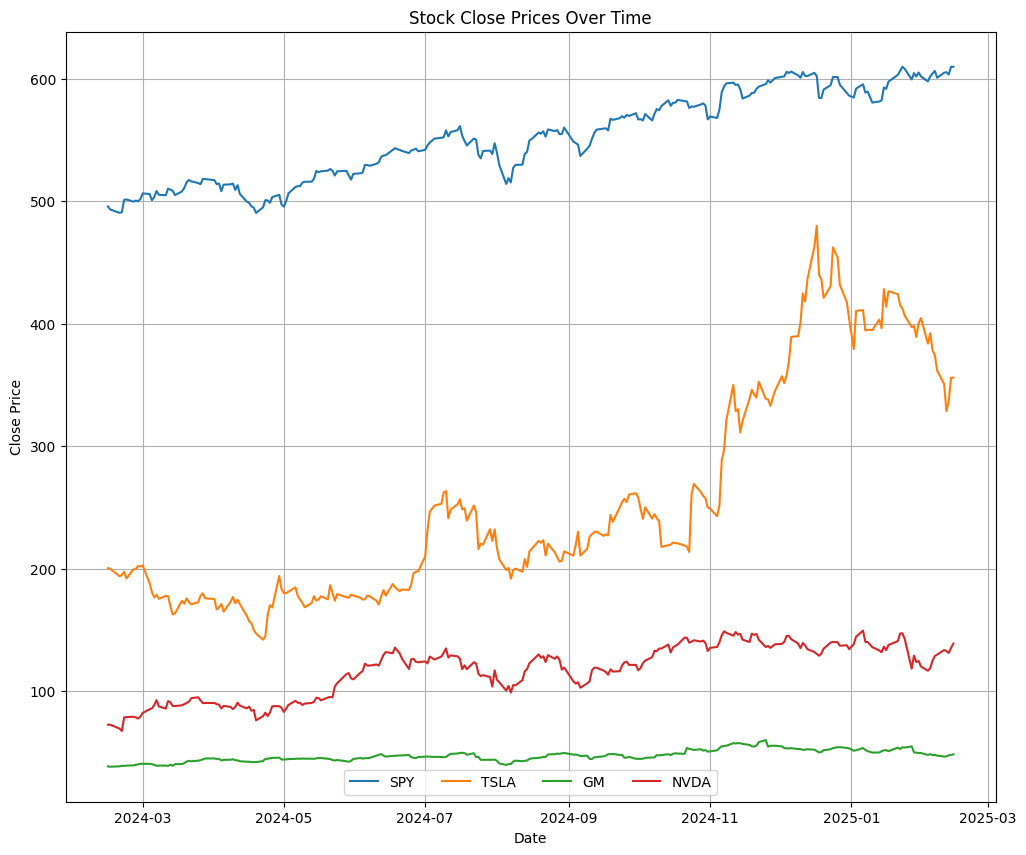

In [ ]:
# Step 1: Create a line chart showing the close prices for all four stocks
plt.figure(figsize=(12, 10))
for company in df['Company'].unique():
    plt.plot(df[df['Company'] == company]['Date'], df[df['Company'] == company]['Close'], label=company)
plt.title('Stock Close Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend(loc='lower center', ncol=4)
plt.grid(True)
plt.show()

In [ ]:
# Step 2: Create Normalized Dataset with New Columns
normalized_df_close = df.pivot(index='Date', columns='Company', values='Close').copy()
for col in normalized_df_close.columns:
    normalized_df_close[col + '_Normalized'] = (normalized_df_close[col] / normalized_df_close[col].iloc[0]) * 100
print(normalized_df_close.head())

Company                           GM       NVDA         SPY        TSLA  \
Date                                                                      
2024-02-15 00:00:00-05:00  38.589005  72.637398  495.652130  200.449997   
2024-02-16 00:00:00-05:00  38.301991  72.592415  493.183777  199.949997   
2024-02-20 00:00:00-05:00  38.608799  69.432312  490.468628  193.759995   
2024-02-21 00:00:00-05:00  39.083866  67.452881  490.912903  194.770004   
2024-02-22 00:00:00-05:00  38.935406  78.515747  501.072601  197.410004   

Company                    GM_Normalized  NVDA_Normalized  SPY_Normalized  \
Date                                                                        
2024-02-15 00:00:00-05:00     100.000000       100.000000      100.000000   
2024-02-16 00:00:00-05:00      99.256229        99.938072       99.501999   
2024-02-20 00:00:00-05:00     100.051296        95.587554       98.954206   
2024-02-21 00:00:00-05:00     101.282390        92.862469       99.043840   
2024-02-22 0

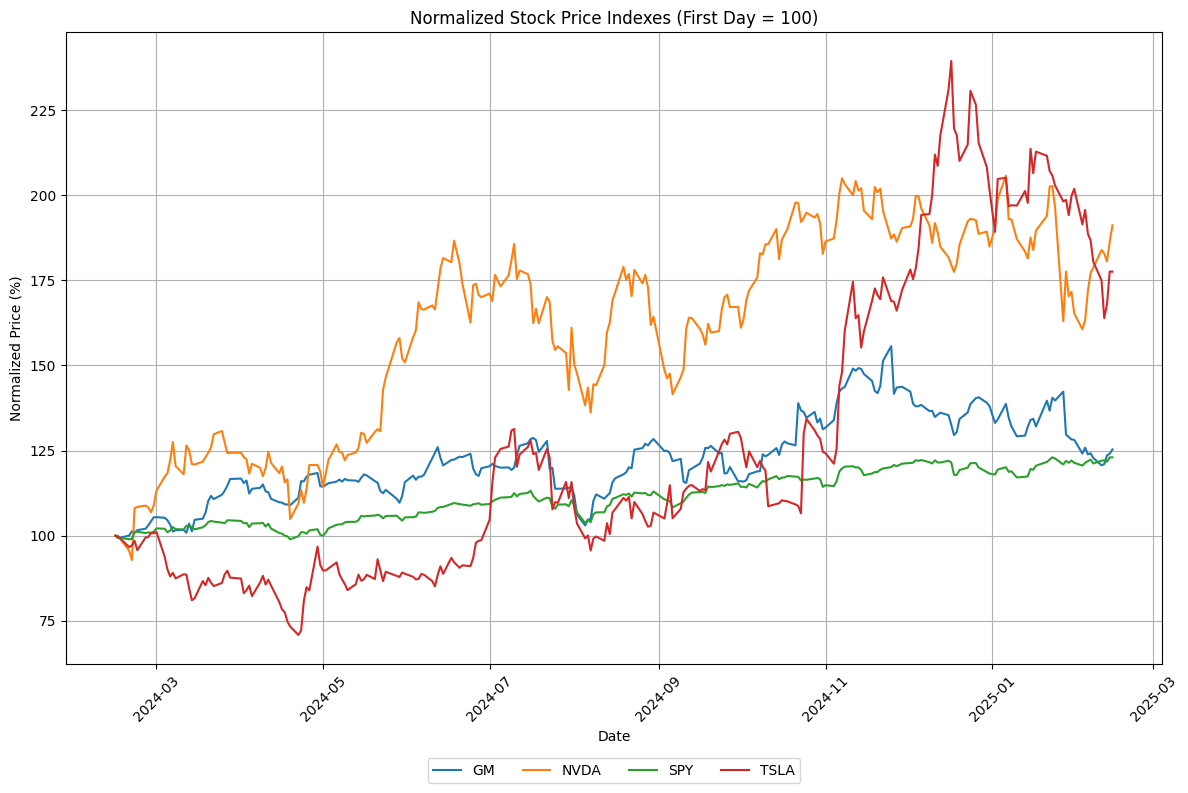

In [ ]:
# Step 3: Line Chart of Normalized Prices
plt.figure(figsize=(12, 8))
for col in normalized_df_close.columns:
    if '_Normalized' in col:
        plt.plot(normalized_df_close.index, normalized_df_close[col], label=col.replace('_Normalized', ''))
plt.title('Normalized Stock Price Indexes (First Day = 100)')
plt.xlabel('Date')
plt.ylabel('Normalized Price (%)')
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=4)
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# B. Daily Return

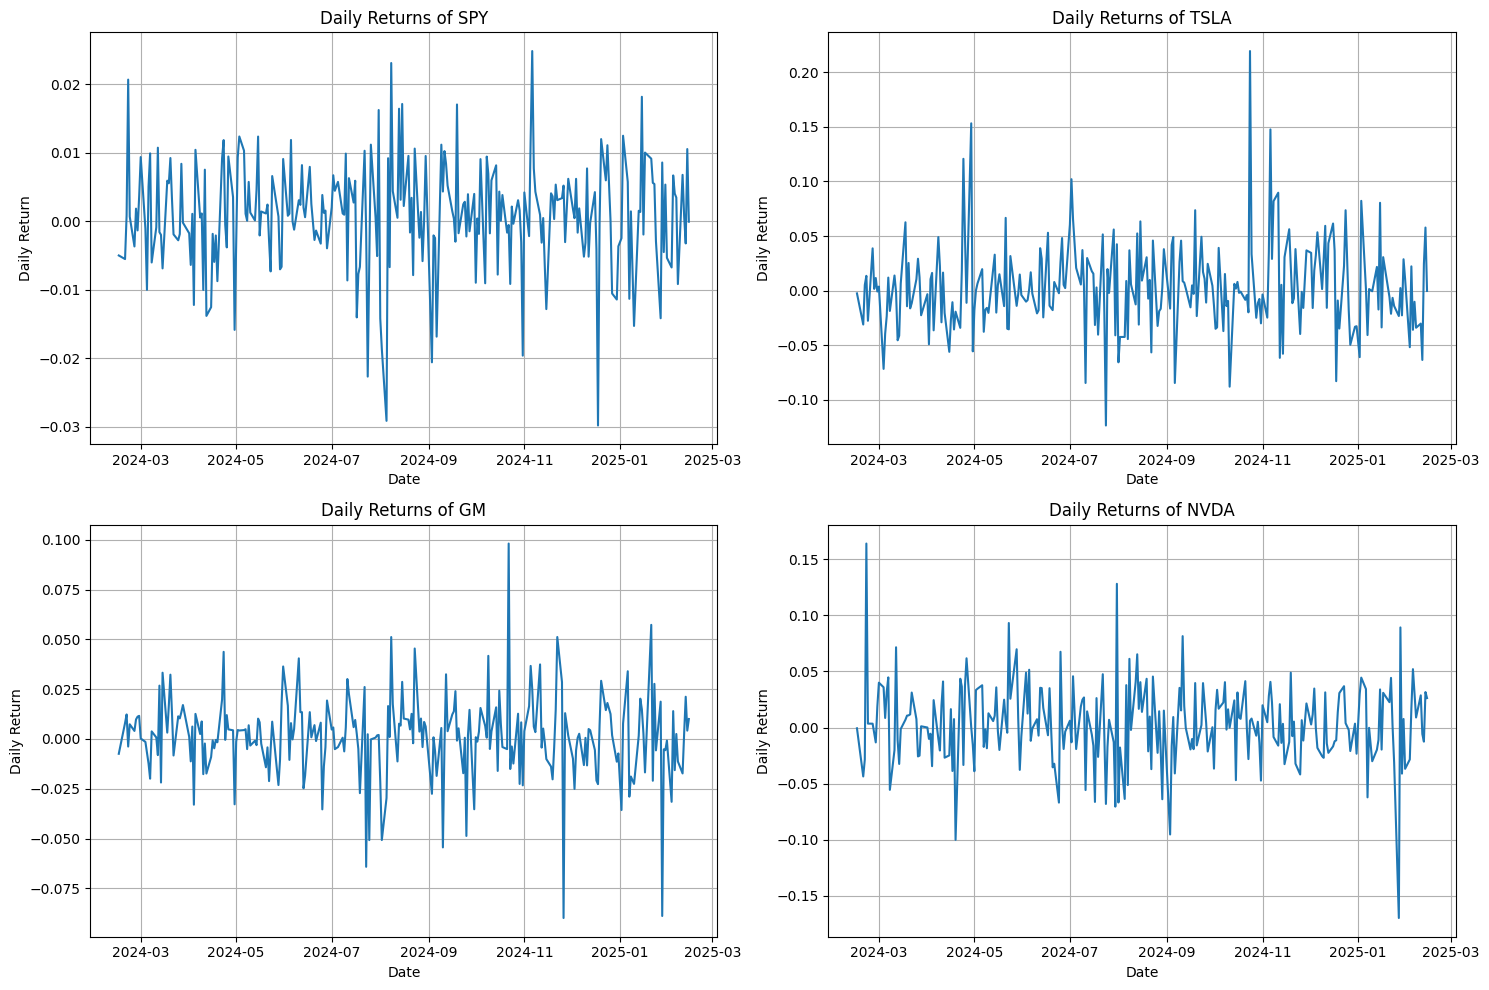

In [ ]:
# Calculate daily returns
daily_returns = df_close.set_index('Date').pct_change()

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot daily returns for each stock
stocks = ['SPY', 'TSLA', 'GM', 'NVDA']
for i, stock in enumerate(stocks):
    row = i // 2
    col = i % 2
    axes[row, col].plot(daily_returns[stock])
    axes[row, col].set_title(f'Daily Returns of {stock}')
    axes[row, col].set_xlabel('Date')
    axes[row, col].set_ylabel('Daily Return')
    axes[row, col].grid(True)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

# C. Distributions of Daily Return

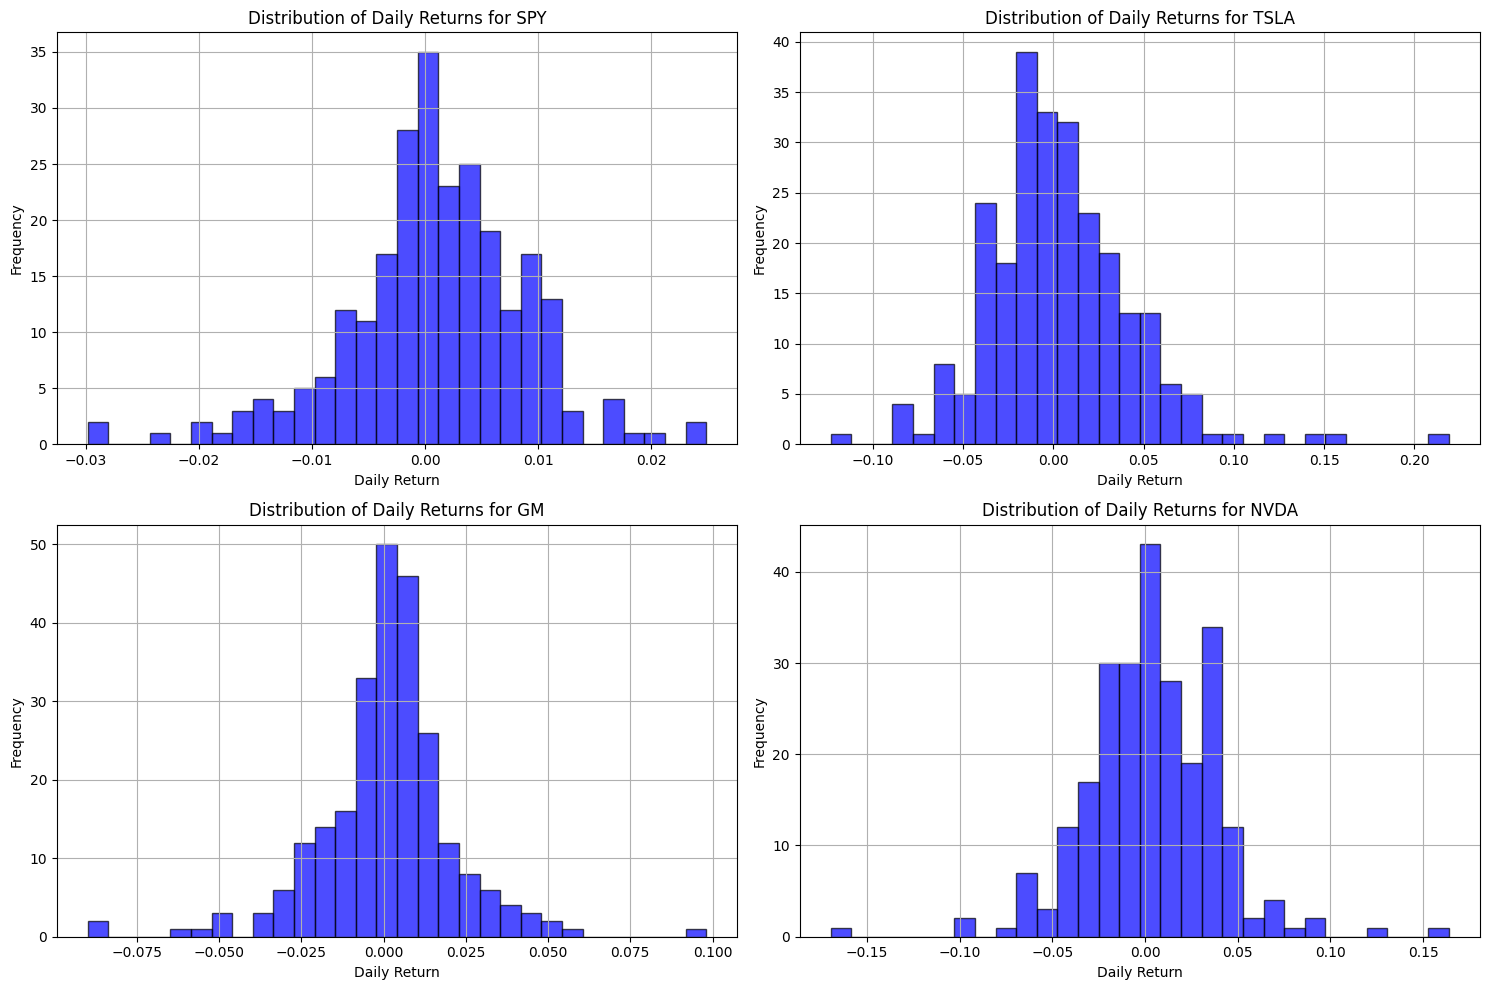

In [ ]:
# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Stocks to plot
stocks = ['SPY', 'TSLA', 'GM', 'NVDA']

# Plot histogram for each stock
for i, stock in enumerate(stocks):
    row, col = divmod(i, 2)
    axes[row, col].hist(daily_returns[stock], bins=30, edgecolor='black', alpha=0.7, color='blue')
    axes[row, col].set_title(f'Distribution of Daily Returns for {stock}')
    axes[row, col].set_xlabel('Daily Return')
    axes[row, col].set_ylabel('Frequency')
    axes[row, col].grid(True)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

# D. Pair Plots for Correlation

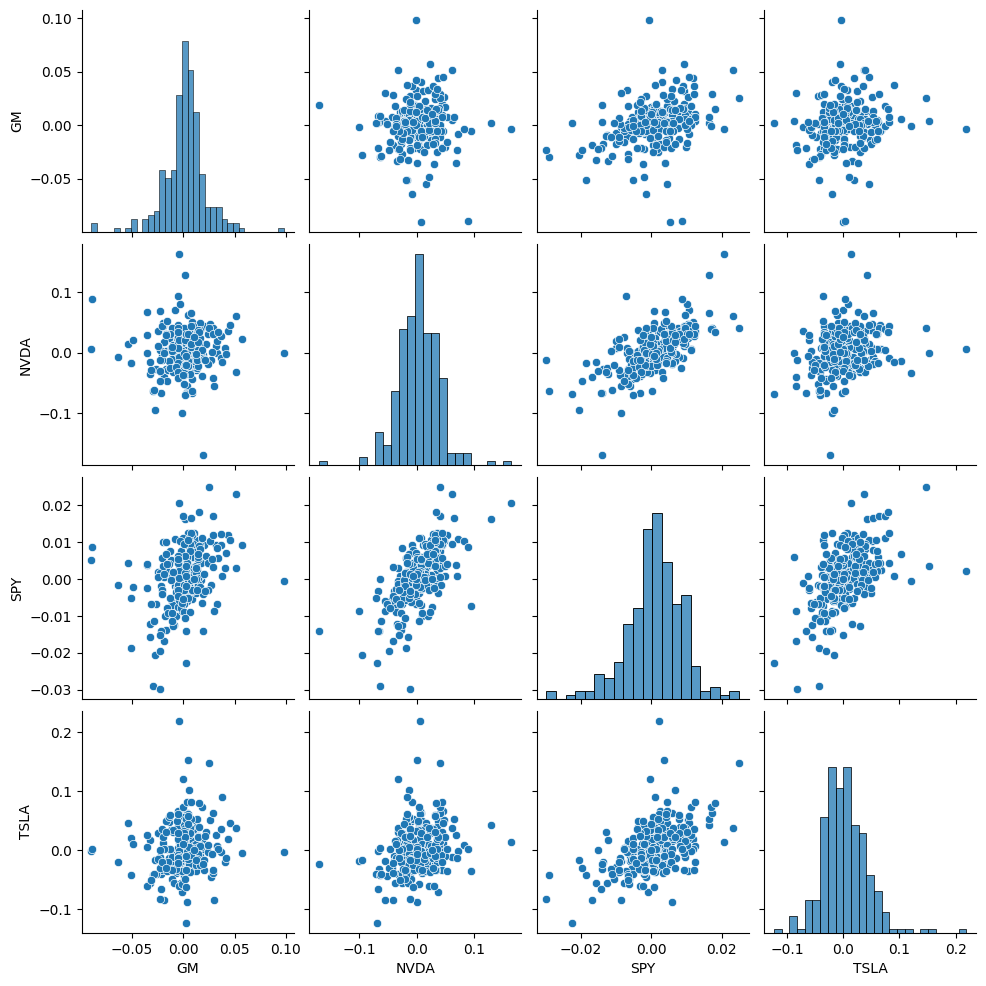

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Drop NaN values from daily returns
daily_returns_clean = daily_returns.dropna()

# Create pair plot
sns.pairplot(daily_returns_clean, kind='scatter', diag_kind='hist')

# Show the plot
plt.show()